In [1]:
import numpy as np
import matplotlib.pyplot as plt

Возьмем матрицу переходов P из предыдущего задания:

In [2]:
P = np.array([
  [0.3399, 0.2253, 0.1414, 0.2934],
  [0.3433, 0.2777, 0.0722, 0.3068],
  [0.3289, 0.2578, 0.1972, 0.2161],
  [0.3608, 0.2318, 0.1137, 0.2937]
  ])

Возведение матрицы в степени до 1000:

In [3]:
nucleotides = ['A', 'C', 'G', 'T']
max_k = 1000
P_powers = []
norms = []

# Начальная матрица P^1
P_current = P.copy()
P_powers.append(P_current)

for k in range(2, max_k + 1):
    P_next = np.linalg.matrix_power(P, k)
    P_powers.append(P_next)

    # Вычисляем норму разности между P^k и P^(k-1)
    diff_norm = np.linalg.norm(P_next - P_current, 'fro')
    norms.append(diff_norm)

    P_current = P_next

    # Выводим несколько промежуточных результатов
    if k in [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000]:
        print(f"\nP^{k}:")
        print("     A      C      G      T")
        for i, from_nuc in enumerate(nucleotides):
            row = P_next[i]
            print(f"  {from_nuc}  ", end="")
            for prob in row:
                print(f"{prob:.6f} ", end="")
            print()



P^2:
     A      C      G      T
  A  0.345243 0.243608 0.125572 0.285577 
  C  0.346462 0.244192 0.117714 0.291632 
  G  0.343124 0.246622 0.128578 0.281676 
  T  0.345576 0.243051 0.123568 0.287805 

P^5:
     A      C      G      T
  A  0.345374 0.243963 0.123451 0.287212 
  C  0.345375 0.243961 0.123449 0.287214 
  G  0.345374 0.243964 0.123450 0.287212 
  T  0.345374 0.243963 0.123451 0.287212 

P^10:
     A      C      G      T
  A  0.345374 0.243963 0.123451 0.287213 
  C  0.345374 0.243963 0.123451 0.287213 
  G  0.345374 0.243963 0.123451 0.287213 
  T  0.345374 0.243963 0.123451 0.287213 

P^20:
     A      C      G      T
  A  0.345374 0.243963 0.123451 0.287213 
  C  0.345374 0.243963 0.123451 0.287213 
  G  0.345374 0.243963 0.123451 0.287213 
  T  0.345374 0.243963 0.123451 0.287213 

P^50:
     A      C      G      T
  A  0.345374 0.243963 0.123451 0.287213 
  C  0.345374 0.243963 0.123451 0.287213 
  G  0.345374 0.243963 0.123451 0.287213 
  T  0.345374 0.243963 0.1234

Покажем, что матрица действительно стабилизируется:

/tmp/ipykernel_271/3384687158.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


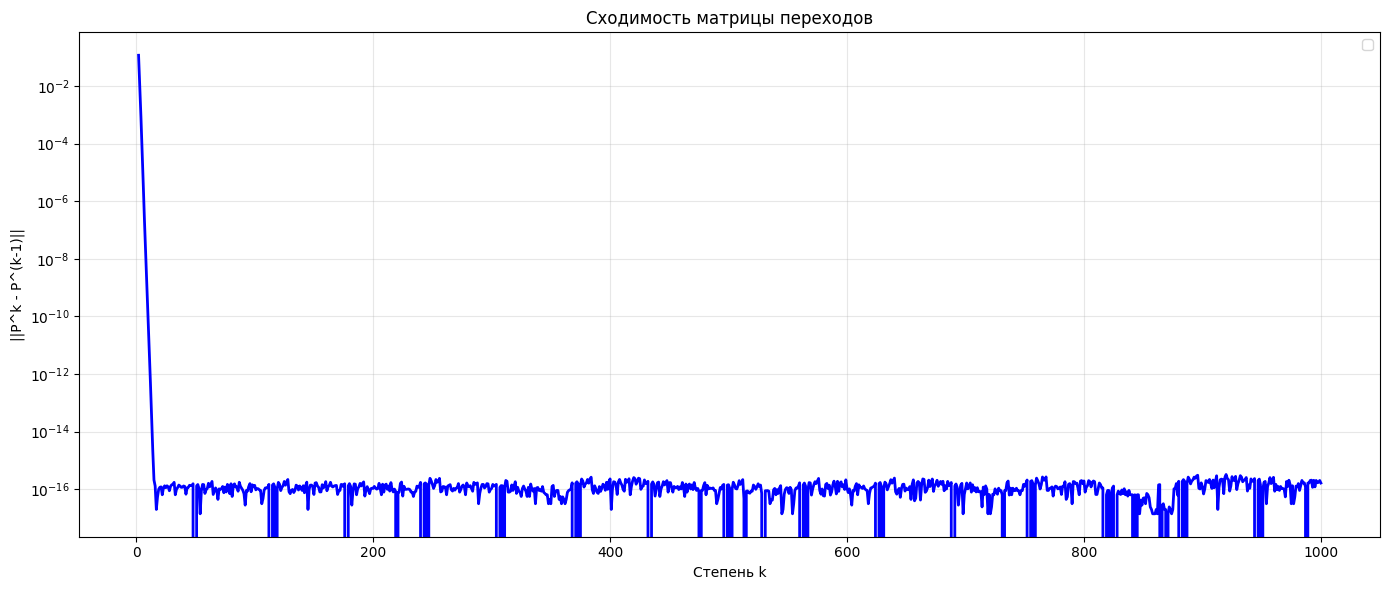

In [5]:
plt.figure(figsize=(14, 6))

k_values = range(2, max_k + 1)
plt.semilogy(k_values, norms, 'b-', linewidth=2)
plt.xlabel('Степень k')
plt.ylabel('||P^k - P^(k-1)||')
plt.title('Сходимость матрицы переходов')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig('convergence_plot.png', dpi=150, bbox_inches='tight')
plt.show()

Видим, что матрица очень быстро стабилизируется

In [10]:
def find_stationary_distribution(P):
    """Находит стационарное распределение марковской цепи"""
    A = P.T - np.eye(4)
    A = np.vstack([A, np.ones(4)])
    b = np.zeros(5)
    b[-1] = 1
    pi, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
    return pi

In [11]:
pi = find_stationary_distribution(P)

In [13]:
print(pi)

[0.34537426 0.24396267 0.12345054 0.28721254]


Выше, где выводили несколько матриц в степенях, видим, что строки приходят к стационарному значению и оно совпадает со значениями стационарного распределения